# ETL-пайплайн подготовки датасета Painterly Spell Icons (289 ассетов) + EDA

**Этапы работы ноутбука:**
1. **Extract (Сбор данных):** Автоматическое скачивание 4-х частей датасета Painterly Spell Icons с OpenGameArt (~289+ изображений 256x256).
2. **Transform (Обработка):** Рекурсивный поиск файлов и гибридная разметка (WD-14 MOAT Tagger + локальная Ollama/LLaVA NLP).
3. **Analyze (Аналитика):** Разведочный анализ (EDA) полученных данных перед подачей в LoRA.

In [1]:
import os
import csv
import base64
import urllib.request
import zipfile
import requests
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import onnxruntime as ort
from huggingface_hub import hf_hub_download

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

e:\Projects\Auto-VideoGame-Assets-Pipeline\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Инициализация папок проекта (Props)
Указываем путь к уже собранному и обработанному датасету Painterly Spell Icons.

In [2]:
import os

if os.path.exists(os.path.join("data", "processed_props_300")):
    DATASET_DIR = os.path.join("data", "processed_props_300")
else:
    DATASET_DIR = os.path.join("..", "data", "processed_props_300")

if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)
    print(f"⚠️ Папка {DATASET_DIR} не найдена. Создана пустая папка.")
else:
    # Рекурсивный поиск изображений в папке
    def get_all_images(directory):
        images = []
        for root, _, files in os.walk(directory):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    images.append(os.path.join(root, file))
        return images
    
    image_paths = get_all_images(DATASET_DIR)
    print(f"✅ Найдено {len(image_paths)} изображений для обработки в папке {DATASET_DIR}")

✅ Найдено 289 изображений для обработки в папке data\processed_props_300


## 2. Инициализация моделей (WD-14 MOAT и Ollama LLaVA)

In [3]:
print("📥 Загрузка весов WD-14 MOAT Tagger...")
model_path = hf_hub_download(repo_id="SmilingWolf/wd-v1-4-moat-tagger-v2", filename="model.onnx")
tags_csv_path = hf_hub_download(repo_id="SmilingWolf/wd-v1-4-moat-tagger-v2", filename="selected_tags.csv")

class LocalWD14Tagger:
    def __init__(self, model_path, tags_csv_path):
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if 'CUDAExecutionProvider' in ort.get_available_providers() else ['CPUExecutionProvider']
        self.session = ort.InferenceSession(model_path, providers=providers)
        
        self.tags = []
        self.categories = []
        with open(tags_csv_path, 'r', encoding='utf-8') as f:
            reader = csv.reader(f)
            next(reader)
            for row in reader:
                self.tags.append(row[1])
                self.categories.append(int(row[2]))
                
    def preprocess(self, image_path):
        img = Image.open(image_path).convert('RGB')
        img = img.resize((448, 448), Image.Resampling.BILINEAR)
        img_data = np.array(img, dtype=np.float32)
        img_data = np.expand_dims(img_data, axis=0)
        return img_data
        
    def predict(self, image_path, threshold=0.35, character_threshold=0.85):
        input_data = self.preprocess(image_path)
        input_name = self.session.get_inputs()[0].name
        outputs = self.session.run(None, {input_name: input_data})
        probs = outputs[0][0]
        
        predicted_tags = []
        for idx, prob in enumerate(probs):
            category = self.categories[idx]
            tag_name = self.tags[idx]
            if category == 0 and prob >= threshold:
                predicted_tags.append(tag_name)
            elif category == 4 and prob >= character_threshold:
                predicted_tags.append(tag_name)
        return predicted_tags

tagger = LocalWD14Tagger(model_path, tags_csv_path)

# Настройки Ollama
TRIGGER_TOKEN = "@spll_icn"
OLLAMA_PROMPT = "describe this image in detail in 100 english words and just give me the description without any extra words from you. don't describe artstyle, small detalization and technique of painting."
OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "llava"

def get_ollama_caption(image_path):
    with open(image_path, "rb") as img_file:
        img_b64 = base64.b64encode(img_file.read()).decode('utf-8')
        
    payload = {
        "model": OLLAMA_MODEL,
        "prompt": OLLAMA_PROMPT,
        "images": [img_b64],
        "stream": False,
        "options": {"temperature": 0.7}
    }
    try:
        response = requests.post(OLLAMA_URL, json=payload)
        response.raise_for_status()
        return response.json().get("response", "").replace("\n", " ").strip()
    except requests.exceptions.RequestException:
        return ""

📥 Загрузка весов WD-14 MOAT Tagger...


## 4. Разведочный анализ данных (EDA)

### Репрезентативные изображения ассетов

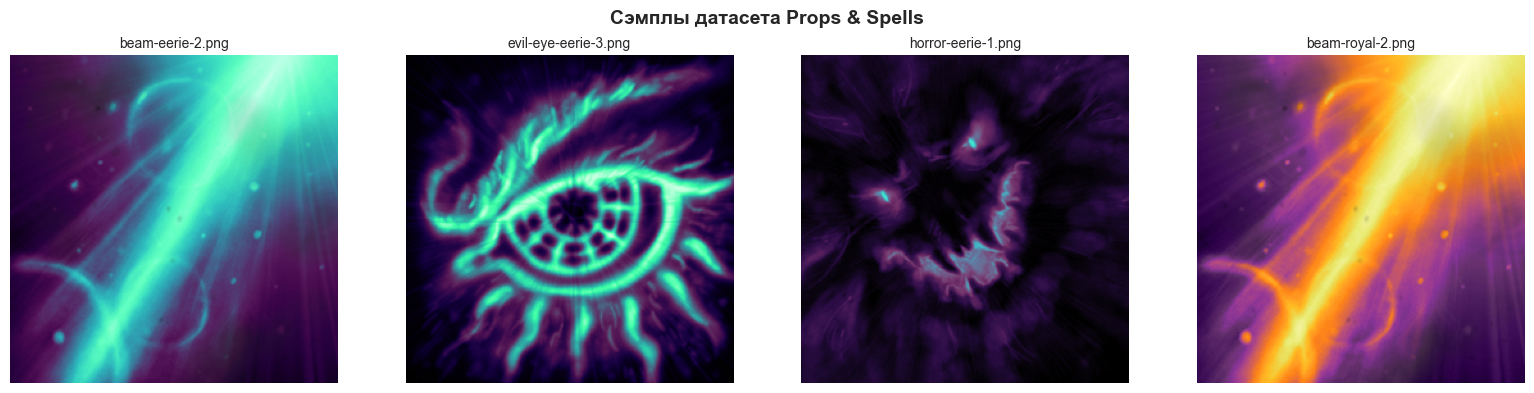

In [8]:
import matplotlib.image as mpimg
import random

if len(image_paths) >= 4:
    sample_images = random.sample(image_paths, 4)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img_path in zip(axes, sample_images):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(os.path.basename(img_path), fontsize=10)
    plt.suptitle('Сэмплы датасета Props & Spells', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Слишком мало изображений для отображения сэмплов.")

In [9]:
booru_tags_counter = Counter()
nlp_lengths = []

txt_files = []
for root, _, files in os.walk(DATASET_DIR):
    for file in files:
        if file.endswith('.txt'):
            txt_files.append(os.path.join(root, file))

if len(txt_files) > 0:
    for txt_path in txt_files:
        with open(txt_path, 'r', encoding='utf-8') as f:
            content = f.read().strip()
            elements = [el.strip() for el in content.split(',') if el.strip()]
            
            for el in elements:
                if len(el) > 30 and el.count(' ') > 5:
                    nlp_lengths.append(len(el.split()))
                else:
                    booru_tags_counter.update([el])

    # Выводим Топ-15 тегов
    df_tags = pd.DataFrame(list(booru_tags_counter.items()), columns=['Tag', 'Frequency'])
    df_tags = df_tags.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
    df_tags = df_tags[df_tags['Tag'] != TRIGGER_TOKEN]
    display(df_tags.head(15))
else:
    print("⚠️ Файлы разметки не найдены.")

,Tag,Frequency
1,no humans,288
2,solo,191
3,pokemon (creature),110
4,black background,108
5,monochrome,82
6,glowing,68
7,simple background,67
8,blue theme,58
9,full body,51
10,still life,50


### 4.0 Очистка датасета от артефактов и редких тегов
Удалим ошибочные классы, которые WD-14 галлюцинировал (pokemon (creature), english text), а также отфильтруем теги с частотой меньше 3 (учитывая малый объем датасета).

In [10]:
MIN_FREQ = 3
GARBAGE_TAGS = {'pokemon (creature)', 'english text'}

if len(txt_files) > 0:
    rare_tags = {tag for tag, count in booru_tags_counter.items() if count < MIN_FREQ}
    tags_to_remove = rare_tags.union(GARBAGE_TAGS)
    
    print(f"Удаляем {len(tags_to_remove)} шумовых и редких тегов...")
    for txt_path in tqdm(txt_files, desc="Очистка аннотаций"):
        with open(txt_path, 'r', encoding='utf-8') as f:
            content = f.read().strip()
        
        elements = [el.strip() for el in content.split(',') if el.strip()]
        filtered_elements = [el for el in elements if el not in tags_to_remove]
        
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(", ".join(filtered_elements))
            
    print("✅ Датасет успешно очищен!")
else:
    print("Нет файлов для очистки.")

Удаляем 327 шумовых и редких тегов...


Очистка аннотаций: 100%|██████████| 290/290 [00:00<00:00, 4850.92it/s]

✅ Датасет успешно очищен!


### Доминирующие визуальные классы

C:\Users\b8914\AppData\Local\Temp\ipykernel_6332\2992260346.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Tag', data=df_dom, palette='Oranges_r')


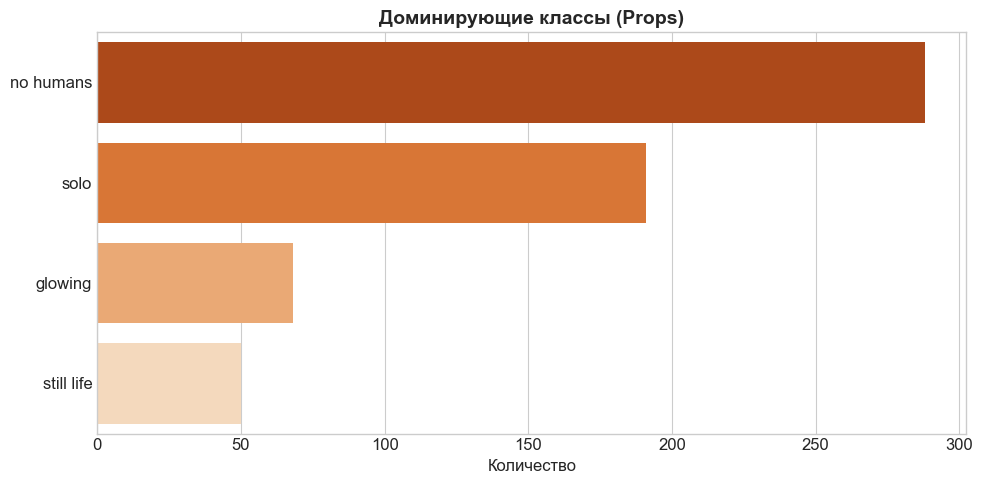

In [11]:
if len(txt_files) > 0:
    dom_tags = ['no humans', 'solo', 'glowing', 'still life']
    dom_data = {t: booru_tags_counter.get(t, 0) for t in dom_tags}
    df_dom = pd.DataFrame(list(dom_data.items()), columns=['Tag', 'Count']).sort_values(by='Count', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Count', y='Tag', data=df_dom, palette='Oranges_r')
    plt.title('Доминирующие классы (Props)', fontsize=14, fontweight='bold')
    plt.xlabel('Количество')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

### 4.1. Спектр категорий магических ассетов

C:\Users\b8914\AppData\Local\Temp\ipykernel_6332\452796472.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Category', data=df_props.sort_values(by='Count', ascending=False), palette='viridis', ax=ax)


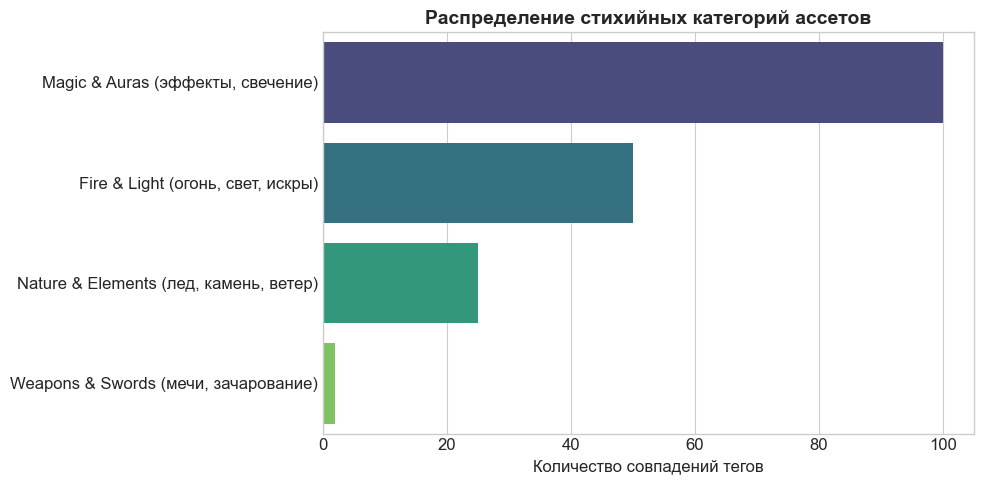

In [12]:
if len(txt_files) > 0:
    # Распределяем теги по стихийным и предметным группам
    categories = {
        'Fire & Light (огонь, свет, искры)': sum(booru_tags_counter[t] for t in ['fire', 'spark', 'light', 'explosion', 'sun', 'yellow background', 'red background']),
        'Nature & Elements (лед, камень, ветер)': sum(booru_tags_counter[t] for t in ['ice', 'stone', 'leaf', 'wind', 'cloud', 'nature', 'tree']),
        'Weapons & Swords (мечи, зачарование)': sum(booru_tags_counter[t] for t in ['sword', 'weapon', 'sharp', 'blade', 'steel']),
        'Magic & Auras (эффекты, свечение)': sum(booru_tags_counter[t] for t in ['magic', 'glowing', 'energy', 'aura', 'sparkles', 'beam'])
    }

    df_props = pd.DataFrame(list(categories.items()), columns=['Category', 'Count'])
    df_props = df_props[df_props['Count'] > 0]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x='Count', y='Category', data=df_props.sort_values(by='Count', ascending=False), palette='viridis', ax=ax)
    plt.title('Распределение стихийных категорий ассетов', fontsize=14, fontweight='bold')
    plt.xlabel('Количество совпадений тегов')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

### 4.2. Плотность NLP-описаний

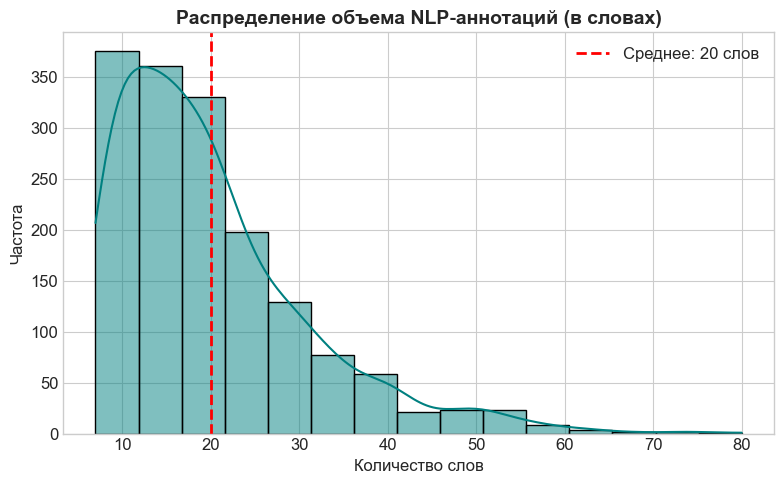

In [13]:
if nlp_lengths:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(nlp_lengths, bins=15, kde=True, color='teal', ax=ax)
    plt.title('Распределение объема NLP-аннотаций (в словах)', fontsize=14, fontweight='bold')
    plt.xlabel('Количество слов')
    plt.ylabel('Частота')
    plt.axvline(np.mean(nlp_lengths), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {int(np.mean(nlp_lengths))} слов')
    plt.legend()
    plt.tight_layout()
    plt.show()